In [ ]:
# !pip install langchain_google_genai langchain_community

In [1]:
import os
from dotenv import load_dotenv

# Load the .env file
load_dotenv()

google_api_key = os.getenv("GOOGLE_API_KEY")
langsmith_api_key = os.getenv("LANGSMITH_API_KEY")

In [2]:
import getpass
import os
from datetime import datetime
import pandas as pd

#Langchain mensajes
from langchain_core.messages import HumanMessage, SystemMessage, AIMessage, ToolMessage

#Langchain chat model (Google)
from langchain_google_genai import ChatGoogleGenerativeAI

#Langchain embedding model (Google)
from langchain_google_genai import GoogleGenerativeAIEmbeddings

#Langchain document loaders
from langchain_core.documents.base import Document
from langchain_community.document_loaders import WebBaseLoader

#Langchain text splitters
from langchain_text_splitters import RecursiveCharacterTextSplitter

#Vector store (Chroma)
from langchain_core.vectorstores import InMemoryVectorStore

#Herramientas
from langchain_core.tools import tool
from langchain_core.runnables.base import RunnableBinding
from langchain_classic.tools.retriever import create_retriever_tool

#Message state
from langgraph.graph.message import MessagesState
from typing import TypedDict, Annotated

#Workflow
from langgraph.graph import StateGraph, START, END
from langgraph.graph.state import CompiledStateGraph
from langgraph.prebuilt import ToolNode
from langgraph.prebuilt import tools_condition

#Memoria
from langgraph.checkpoint.memory import MemorySaver
from langgraph.checkpoint.memory import InMemorySaver

#Langsmith
from langsmith import Client

from IPython.display import Image, display

C:\Users\Nitvn\AppData\Local\Temp\ipykernel_14192\560487343.py:17: DeprecationWarning: `langchain-community` is being sunset and is no longer actively maintained. See https://github.com/langchain-ai/langchain-community/issues/674 for details and migration guidance toward standalone integration packages.
  from langchain_community.document_loaders import WebBaseLoader
USER_AGENT environment variable not set, consider setting it to identify your requests.


#### LangSmith API keys

In [3]:
os.environ["LANGSMITH_TRACING"] = "true"
os.environ["LANGSMITH_PROJECT"] = "LangSmith_Fundamentos"

In [4]:
# Ingresa el API key - Gemini
# os.environ["GOOGLE_API_KEY"]: str = getpass.getpass("Ingresa tu Google AI API key: ")

In [5]:

# Ingresa el API key - LangSmith
# os.environ["LANGSMITH_API_KEY"]: str = getpass.getpass("Ingresa tu Google AI API key: ")

In [6]:
#Inicializamos nuestro modelo chat
llm: ChatGoogleGenerativeAI = ChatGoogleGenerativeAI(model="gemini-2.5-flash", temperature=0)

####**Creación y gestión del dataset**

Evaluemos las respuestas de la apliación RAG que utiliza la información del siguiente enlace: https://www.ibm.com/es-es/think/topics/large-language-models

In [7]:
#Definimos la lista de ejemplos para nuestro dataset de evaluación

Ejemplos = [
  {
    "inputs": {"pregunta": "¿Qué son los grandes modelos de lenguaje (LLM)?"},
    "outputs": {"respuesta": "Los LLM son una categoría de modelos fundacionales entrenados sobre inmensas cantidades de datos, capaces de comprender y generar lenguaje natural y otros tipos de contenido para realizar una amplia variedad de tareas."},
  },
  {
    "inputs": {"pregunta": "¿Qué arquitectura de machine learning es la base de los LLM según la página?"},
    "outputs": {"respuesta": "Los LLM suelen basarse en una arquitectura de transformador, como el transformador generativo preentrenado, que destaca en el manejo de datos secuenciales como la entrada de texto."},
  },
  {
    "inputs": {"pregunta": "Menciona dos tácticas utilizadas para aumentar el rendimiento de un LLM y reducir respuestas indeseadas (como las alucinaciones)."},
    "outputs": {"respuesta": "Para aumentar el rendimiento se puede utilizar el prompt engineering, el ajuste fino (fine-tuning), y el aprendizaje reforzado con feedback humano (RLHF), que ayuda a eliminar sesgos y 'alucinaciones'."},
  },
  {
    "inputs": {"pregunta": "¿Cuál es el propósito de la serie de modelos Granite de IBM?"},
    "outputs": {"respuesta": "IBM ha lanzado su serie de modelos Granite en watsonx.ai, que se ha convertido en la columna vertebral de la IA generativa para otros productos de IBM como watsonx Assistant y watsonx Orchestrate."},
  },
]

In [8]:
#Inicializamos el cliente de LangSmith
client = Client()
dataset_name = "IBM Respuestas"

#Creamos el Dataset
dataset = client.create_dataset(
   dataset_name=dataset_name
  ,description="Dataset para evaluar aplicación RAG con documentos extraídos de: https://www.ibm.com/es-es/think/topics/large-language-models",
)

#Cargamos el dataset
client.create_examples(
  dataset_id=dataset.id,
  examples=Ejemplos
)

{'example_ids': ['1cf70425-75ef-49d5-ad44-aa0878cda1ba',
  '6d2d2356-d155-48fa-bbef-260426703077',
  '443a1bda-a191-4d7f-8a5e-4ad4c510a312',
  '7f4558ca-b572-4064-ac40-7ab32c0403e4'],
 'count': 4,
 'as_of': '2026-07-11T21:20:32.517911836Z'}

In [11]:
#Eliminar Dataset
client.delete_dataset(dataset_name=dataset_name)

In [9]:
import os

root_path = os.getcwd()

print(root_path)

c:\Users\Nitvn\Documentos\Dev\generative-ai-tools\langsmith-rag


In [12]:
#Cargar Dataset desde un csv
client.upload_csv(
    csv_file=root_path + "/Data/Dataset.csv",
    input_keys=["pregunta"],
    output_keys=["respuesta"],
    name=dataset_name
    )

Dataset(name='IBM Respuestas', description=None, data_type=<DataType.kv: 'kv'>, id=UUID('66d093c7-90f3-49d6-88fb-4f9e7b90949d'), created_at=datetime.datetime(2026, 7, 11, 21, 29, 30, 305242, tzinfo=TzInfo(0)), modified_at=datetime.datetime(2026, 7, 11, 21, 29, 30, 305242, tzinfo=TzInfo(0)), example_count=None, session_count=0, last_session_start_time=None, inputs_schema=None, outputs_schema=None, transformations=None, metadata=None)

In [13]:
#Eliminar Dataset
client.delete_dataset(dataset_name=dataset_name)

In [14]:
#Cargar Dataset con pandas
df = pd.read_csv(root_path + "/Data/Dataset.csv")

dataset = client.upload_dataframe(
    df=df,
    input_keys=["pregunta"],
    output_keys=["respuesta"],
    name=dataset_name,
)

In [15]:
#Listar Datasets
datasets = client.list_datasets()
for dataset in datasets:
  print(dataset)
  print('================')

name='IBM Respuestas' description=None data_type=<DataType.kv: 'kv'> id=UUID('2e742f3c-5743-4fae-865c-851954870723') created_at=datetime.datetime(2026, 7, 11, 21, 31, 34, 619980, tzinfo=TzInfo(0)) modified_at=datetime.datetime(2026, 7, 11, 21, 31, 34, 619980, tzinfo=TzInfo(0)) example_count=7 session_count=0 last_session_start_time=None inputs_schema=None outputs_schema=None transformations=None metadata=None


In [16]:
#Obtener Dataset por nombre
datasets = client.list_datasets(dataset_name=dataset_name)
for dataset in datasets:
  print(dataset)
  print('================')

name='IBM Respuestas' description=None data_type=<DataType.kv: 'kv'> id=UUID('2e742f3c-5743-4fae-865c-851954870723') created_at=datetime.datetime(2026, 7, 11, 21, 31, 34, 619980, tzinfo=TzInfo(0)) modified_at=datetime.datetime(2026, 7, 11, 21, 31, 34, 619980, tzinfo=TzInfo(0)) example_count=7 session_count=0 last_session_start_time=None inputs_schema=None outputs_schema=None transformations=None metadata=None


In [17]:
#Listar ejemplos
ejemplos = client.list_examples(dataset_name=dataset_name)
for ejemplo in ejemplos:
  print(ejemplo)
  print('================')

dataset_id=UUID('2e742f3c-5743-4fae-865c-851954870723') inputs={'pregunta': '¿Cómo contribuyen los LLM al sector de desarrollo de cÃ³digo?'} outputs={'respuesta': 'Los LLMs ayudan a los desarrolladores a crear aplicaciones, encontrar errores en el código, descubrir problemas de seguridad, e incluso "traducir" entre lenguajes de programacón.'} metadata={} id=UUID('019bee33-f950-4066-aa02-a22f8ebc2ddd') created_at=datetime.datetime(2026, 7, 11, 21, 31, 34, 619458, tzinfo=TzInfo(0)) modified_at=datetime.datetime(2026, 7, 11, 21, 31, 34, 619458, tzinfo=TzInfo(0)) source_run_id=None attachments={}
dataset_id=UUID('2e742f3c-5743-4fae-865c-851954870723') inputs={'pregunta': '¿Qué son los grandes modelos de lenguaje (LLM)?'} outputs={'respuesta': 'Los LLM son una categoría de modelos fundacionales entrenados sobre inmensas cantidades de datos, capaces de comprender y generar lenguaje natural y otros tipos de contenido para realizar una amplia variedad de tareas.'} metadata={} id=UUID('4f319e37

In [18]:
#Agregar ejemplos al dataset
client.create_examples(
    examples=[{
        "inputs": {"pregunta": "Pregunta Dummy"},
        "outputs": {"respuesta": "Respuesta Dummy"}
    }],
    dataset_name=dataset_name,
)

{'example_ids': ['59fbce0e-a2b6-42a5-9158-c951e86faf9f'],
 'count': 1,
 'as_of': '2026-07-11T21:34:45.7547675Z'}

In [19]:
#Eliminar ejemplos del dataset
client.delete_example(
        example_id='59fbce0e-a2b6-42a5-9158-c951e86faf9f'
    )

#### **Aplicación 02:** RAG

In [20]:
#El módulo GoogleGenerativeAIEmbeddings nos permite acceder al modelo de gemini
embedding_model: GoogleGenerativeAIEmbeddings = GoogleGenerativeAIEmbeddings(model="models/gemini-embedding-001")

In [21]:
#WebBaseLoader carga información de la web y transforma el código html en documentos - requiere la dirección de la página web
loader: WebBaseLoader = WebBaseLoader("https://www.ibm.com/es-es/think/topics/large-language-models")

#Luego de instanciar la clase, se pueden cargar los documentos con el método load
documento_web: list = loader.load()

In [23]:
# Este loader trata de separa el texto primero en párrafos, luego en oraciones y por último en palabras
splitter_documento: RecursiveCharacterTextSplitter = RecursiveCharacterTextSplitter(
    chunk_size=500,
    chunk_overlap=0,
    length_function=len
)

#Con el método split_documentos se dividen los documentos
textos_split_recursive: list[Document] = splitter_documento.split_documents(documento_web)

In [24]:
#Utilizamos un vector store en memoria
vectorstore = InMemoryVectorStore.from_documents(
    documents=textos_split_recursive, embedding=embedding_model
)
retriever = vectorstore.as_retriever()

In [25]:
#Esta herramienta nos permite usar nuestro retriever como una herramienta
@tool
def retriever_tool(query: str):
    """Recupera documentos relevantes acerca de modelos LLM"""
    return retriever.invoke(query)

In [26]:
#Anexamos las herramientas al modelo
tools: list = [retriever_tool]
modelo: RunnableBinding = llm.bind_tools( tools )

In [27]:
#Definición del estado del grafo
class Estado(MessagesState):
    ...

In [28]:
mensaje_sistema: SystemMessage = SystemMessage(
    'Eres un asistente experto en Modelos de Lenguaje Grandes (LLMs).'
    'Tu objetivo es responder preguntas, explicar conceptos complejos y ayudar al usuario a entender el funcionamiento, la arquitectura y las aplicaciones de los LLMs.'
    'Proporciona respuestas claras, precisas y bien estructuradas.')

def asistente(state: MessagesState) -> MessagesState:
  """
  Genera una respuesta del modelo usando el estado actual.

  Args:
      state (MessagesState): Mensajes previos del flujo.

  Returns:
      MessagesState: Nuevo estado con la respuesta generada.
  """
  prompt: SystemMessage = mensaje_sistema
  response: AIMessage = modelo.invoke([prompt] + state["messages"])
  return {"messages": [response]}

In [29]:
workflow: StateGraph = StateGraph(Estado)
workflow.set_entry_point("Asistente")

#Nodo asistente
workflow.add_node("Asistente", asistente)

#Nodo Herramienta
tool_node: ToolNode = ToolNode(tools=tools) #Se define un nodo especial para el llamado de las herramientas
workflow.add_node("tools", tool_node)

#Condición: tool_condition permite identificar si se realizó una llamada a una herramienta
workflow.add_conditional_edges(
    "Asistente",
    tools_condition,
)

workflow.add_edge("tools", "Asistente")

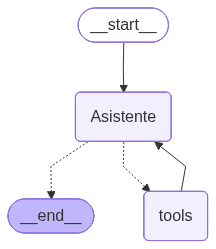

In [30]:
#Compilamos el workflow
workflow_compilado: CompiledStateGraph = workflow.compile()

display(Image(workflow_compilado.get_graph().draw_mermaid_png()))

In [31]:
async def app(inputs: dict) -> dict:
  """
    Invoca el flujo de trabajo compilado asíncrono y extrae el contenido
    de la última respuesta del modelo.

    Esta función sirve como capa de adaptación entre el formato de entrada
    del evaluador de LangSmith (un dict) y el formato de invocación
    del workflow (otro dict).

    Args:
        inputs (dict): Diccionario de entrada de LangSmith que debe contener
                       la clave 'pregunta' con el prompt del usuario.

    Returns:
        dict: Un diccionario con la clave 'respuesta' que contiene el texto
              del contenido del último mensaje generado por el modelo.
    """

  mensajes_wf = await workflow_compilado.ainvoke({'messages': inputs['pregunta']})
  ultima_respuesta = mensajes_wf['messages'][-1].content

  if isinstance(ultima_respuesta, list):
    ultima_respuesta = ultima_respuesta[0]

    if 'text' in ultima_respuesta:
      ultima_respuesta = ultima_respuesta['text']

  return {"respuesta": ultima_respuesta}

####**Evaluación de aplicación**

In [34]:
#Inicializamos nuestro modelo chat
llm_eval: ChatGoogleGenerativeAI = ChatGoogleGenerativeAI(model="gemini-2.5-flash", temperature=0.75)

judge_instrucciones = """Eres un evaluador de respuestas.

Recibirás una PREGUNTA, una RESPUESTA CORRECTA (esperada) y la RESPUESTA DE LA APLICACIÓN.

Criterios de evaluación:
1. Califica únicamente la precisión factual de la respuesta de la aplicación en relación con la respuesta esperada.
2. Asegúrate de que la respuesta de la aplicación no contenga contradicciones o afirmaciones erróneas.
3. Está permitido que la respuesta de la aplicación incluya información adicional, siempre y cuando sea verdadera y no contradiga la respuesta esperada.

Puntaje:
Debes asignar una puntuación entre 0 y 1, donde:
- 1.0 significa que la respuesta es completamente correcta,
- Valores intermedios como 0.5, 0.4, etc. significan que la respuesta es parcialmente correcta.
- 0.0 significa que la respuesta es completamente incorrecta,
- valores intermedios reflejan respuestas parcialmente correctas.

Además, explica tu razonamiento de forma resumida, no más de una línea.
"""

#Esquema de evaluación
class Grade(TypedDict):
    """Compara la resppuesta con la respuesta esperada"""
    reasoning: Annotated[str, ..., "explica tu razonamiento de forma resumida"]
    score: Annotated[float, ..., "respuesta entre 1 y 0, 0 para respuestas completamente incorrectas y 1 para las correctas. Valores intermedios como 0.5, 0.4 significan que la respuesta es parcialmente correcta."]

#Juez LLM
juez_llm = llm_eval.with_structured_output(Grade, method="json_schema", strict=True)

#Función de evaluación
async def evaluador(inputs: dict, outputs: dict, reference_outputs: dict) -> bool:
    """Evalúa si la respuesta final es coherente con la esperada"""

    user = f"""Pregunta: {inputs['pregunta']}
    Respuesta esperada: {reference_outputs['respuesta']}
    Respuesta de la aplicación: {outputs['respuesta']}"""

    nota = await juez_llm.ainvoke([{"role": "system", "content": judge_instrucciones}, {"role": "user", "content": user}])
    return nota["score"]

In [35]:
#Ejecución de la evaluación
experiment_results = await client.aevaluate(
    app,
    data=dataset_name,
    evaluators=[evaluador],
    experiment_prefix="RAG",
    num_repetitions=1,
    max_concurrency=0,
)
experiment_results.to_pandas()

View the evaluation results for experiment: 'RAG-b07ef459' at:
https://smith.langchain.com/o/12a7beac-1159-486d-a3bf-07c617d75cca/datasets/2e742f3c-5743-4fae-865c-851954870723/compare?selectedSessions=a879d4c1-40c3-44cf-999f-ebf62025da4b




7it [00:57,  8.17s/it]


,inputs.pregunta,outputs.respuesta,error,reference.respuesta,feedback.evaluador,execution_time,example_id,id
0,¿Cómo contribuyen los LLM al sector de desarro...,Los Modelos de Lenguaje Grandes (LLM) contribu...,None,Los LLMs ayudan a los desarrolladores a crear ...,1.0,5.459719,019bee33-f950-4066-aa02-a22f8ebc2ddd,019f532b-52a7-78f0-8cb2-2c10dc9e8eac
1,¿Qué son los grandes modelos de lenguaje (LLM)?,"Los Grandes Modelos de Lenguaje (LLM, por sus ...",None,Los LLM son una categoría de modelos fundacion...,1.0,4.725508,4f319e37-09c3-436f-a316-c3ec62343199,019f532b-7447-7402-b8e1-cfc1141f8457
2,¿Qué tipo de aprendizaje se emplea en el entre...,El tipo de aprendizaje que se emplea en el ent...,None,El entrenamiento con el corpus masivo implica ...,1.0,1.906404,5c0b6cdc-8f54-4a05-850f-68ece21753b6,019f532b-9045-7910-a140-105937629351
3,¿Qué arquitectura de machine learning es la ba...,"Según la página, la arquitectura de machine le...",None,Los LLM suelen basarse en una arquitectura de ...,1.0,3.919696,8ac9fbbb-48a3-49fa-93a7-0615e792b450,019f532b-a6be-71d1-b903-1d07b32f4ca0
4,¿Cuál es el propósito de la serie de modelos G...,La serie de modelos IBM Granite es una familia...,None,IBM ha lanzado su serie de modelos Granite en ...,1.0,4.487912,b9631c32-e8b4-4f98-827f-214e219a05db,019f532b-c2b2-78e2-bfd6-d1f8375cb8f4
5,"Además de la generación de texto y código, qué...","Además de la generación de texto y código, otr...",None,Otras aplicaciones importantes incluyen el res...,1.0,3.352002,d74ef2c0-f748-4f20-a324-084e48418176,019f532b-dc03-7fe1-88d3-afa21abd2c1b
6,Menciona dos tácticas utilizadas para aumentar...,Aquí tienes dos tácticas utilizadas para aumen...,None,Para aumentar el rendimiento se puede utilizar...,1.0,7.301507,f272a257-a581-4420-87fc-c90697a1142d,019f532b-ffbc-7201-b2a2-043f617c9b7b
